In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

%matplotlib inline

In [ ]:
class Cond:
    """Solve the condensation/evaporation from dust of fixed size. 
    
    A full analytic expression is used for the density. The velocity is
    solved analytically, but using the final density.
    """
    def __init__(self, rho_t, rho_v, K):
        self._rho_t = rho_t 
        self._rho_v = rho_v 
        self._K = K 

    def __call__(self, rho0, dt):
        rho_p = self._rho_t - self._rho_v 

        if rho_p != 0:
            x = self._K * rho_p * dt 

            return rho0 / (np.exp(-x) - rho0/rho_p * np.expm1(-x))
        else:
            return rho0 / (1 + self._K*rho0*dt)

    def vels(self, rho0, dt, v0, vg=0): 
        # Approximate solution using rho(dt) and equation for dv/dt.
        
        md = rho0 * v0
        mg = (self._rho_t - rho0) * vg
        mt = md + mg

        rho_d = self(rho0, t)
        rho_g = self._rho_t -  rho_d
        
        x = self._K*dt*(rho_g + rho_d*self._rho_v/rho_g)

        dv = (v0 - vg) * np.exp(-x)
        vd = (mt + rho_g*dv)/self._rho_t
        vg = vd-dv 
        return vd, vg



        

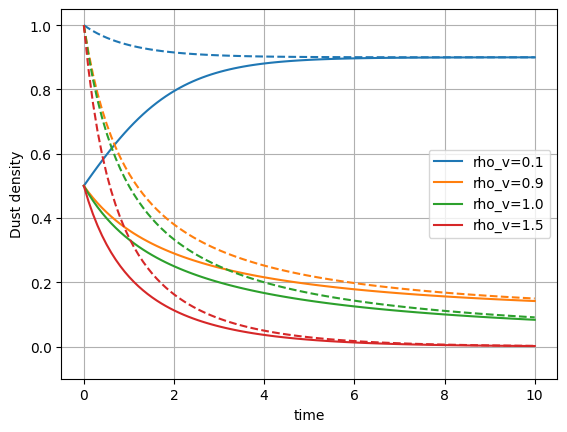

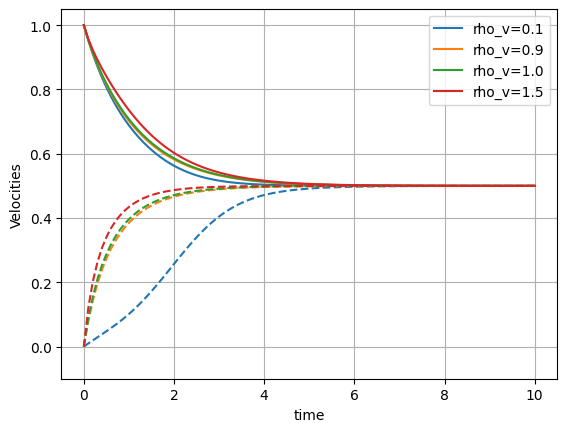

In [3]:
t = np.linspace(0, 10, 100)

for rho_v in [0.1, 0.9, 1.0, 1.5]:
    cond = Cond(1.0, rho_v, 1.0)

    c = None
    for rho_d, ls in zip([0.5, 1.0], ['-', '--']):
        rho_t = cond(rho_d, t)

        label = None if ls != '-' else f'rho_v={rho_v}'
        c = plt.plot(t, rho_t, ls=ls, c=c, label=label)[0].get_color()
        #plt.plot(t, cond.approx(rho_d, t), ls=':', c=c)

plt.xlabel('time')
plt.ylabel('Dust density')
plt.ylim(ymin=-0.1)
plt.grid()
plt.legend()

plt.figure()
for rho_v in [0.1, 0.9, 1.0, 1.5]:
    cond = Cond(1.0, rho_v, 1.0)

    vd, vg = cond.vels(0.5, t, 1.0)
    c = plt.plot(t, vd, label=f'rho_v={rho_v}')[0].get_color()
    plt.plot(t, vg, c=c, ls='--')
plt.xlabel('time')
plt.ylabel('Velocities')
plt.ylim(ymin=-0.1)
plt.grid()
plt.legend()



